# QC and filter seurat object

In [27]:
options(warn=-1)

In [28]:
library_load <- suppressMessages(
    
    list(
        
        # Seurat 
        library(Seurat), 
        
        # Data 
        library(tidyverse), 
        
        # Plotting 
        library(ggplot2), 
        library(patchwork), 
        
        # Pyhton compatibility
        library(reticulate)
        
    )
    
)

In [29]:
# Configure reticulate 
use_condaenv(condaenv='p.3.8.12-FD20220623HSCT', conda="/nobackup/peer/fdeckert/miniconda3/bin/conda", required=NULL)
py_config()

python:         /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT/bin/python
libpython:      /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT/lib/libpython3.8.so
pythonhome:     /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT:/nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT
version:        3.8.12 | packaged by conda-forge | (default, Jan 30 2022, 23:42:07)  [GCC 9.4.0]
numpy:          /nobackup/peer/fdeckert/miniconda3/envs/p.3.8.12-FD20220623HSCT/lib/python3.8/site-packages/numpy
numpy_version:  1.22.4

NOTE: Python version was forced by use_python() function

In [30]:
random_seed <- 42
set.seed(random_seed)

In [31]:
# Set working directory to project root
setwd("/research/peer/fdeckert/FD20220623HSCT")

In [32]:
# Source files
source("plotting_global.R")
source("bin/seurat_qc.R")

# Parameter settings

In [33]:
# Files 
raw_rds_file <- "../reference/scRNAseq/data/reynolds_et_al/data/human_adult_raw.rds"
qc_rds_file <- "data/object/reynolds_et_al_2021/qc.rds"
qc_h5ad_file <- "data/object/reynolds_et_al_2021/qc.h5ad"

# Plotting Theme
ggplot2::theme_set(theme_global_set(size_select=1)) # From project global source()

# Import Seurat object

In [34]:
so_qc <- readRDS(raw_rds_file)

# Compute cell cycle score 

In [11]:
# Compute cell cycle score 
so_qc <- CellCycleScoring(so_qc, s.features=cc.genes.updated.2019$s.genes, g2m.features=cc.genes.updated.2019$g2m.genes, set.ident=FALSE)

colnames(so_qc@meta.data) <- gsub("Phase", "cc_phase_class", colnames(so_qc@meta.data))
colnames(so_qc@meta.data) <- gsub("S.Score", "msS_RNA", colnames(so_qc@meta.data))
colnames(so_qc@meta.data) <- gsub("G2M.Score", "msG2M_RNA", colnames(so_qc@meta.data))
    
so_qc$msCC_diff_RNA <- so_qc$msS_RNA - so_qc$msG2M_RNA
so_qc$cc_phase_class <- factor(so_qc$cc_phase_class, levels=names(color$cc_phase_class))

# CellTypist

In [12]:
celltypist_low <- read.csv("result/reynolds_et_al_2021/celltypist/immune_all_low.csv", row.names=1)
colnames(celltypist_low) <- "celltypist_predicted_labels_low"

In [13]:
celltypist_high <- read.csv("result/reynolds_et_al_2021/celltypist/immune_all_high.csv", row.names=1)
colnames(celltypist_high) <- "celltypist_predicted_labels_high"

In [14]:
so_qc <- AddMetaData(so_qc, celltypist_low)
so_qc <- AddMetaData(so_qc, celltypist_high)

# Solo doublets 

In [15]:
solo <- read.csv("result/reynolds_et_al_2021/solo/solo.csv", row.names=1)
so_qc <- AddMetaData(so_qc, solo)

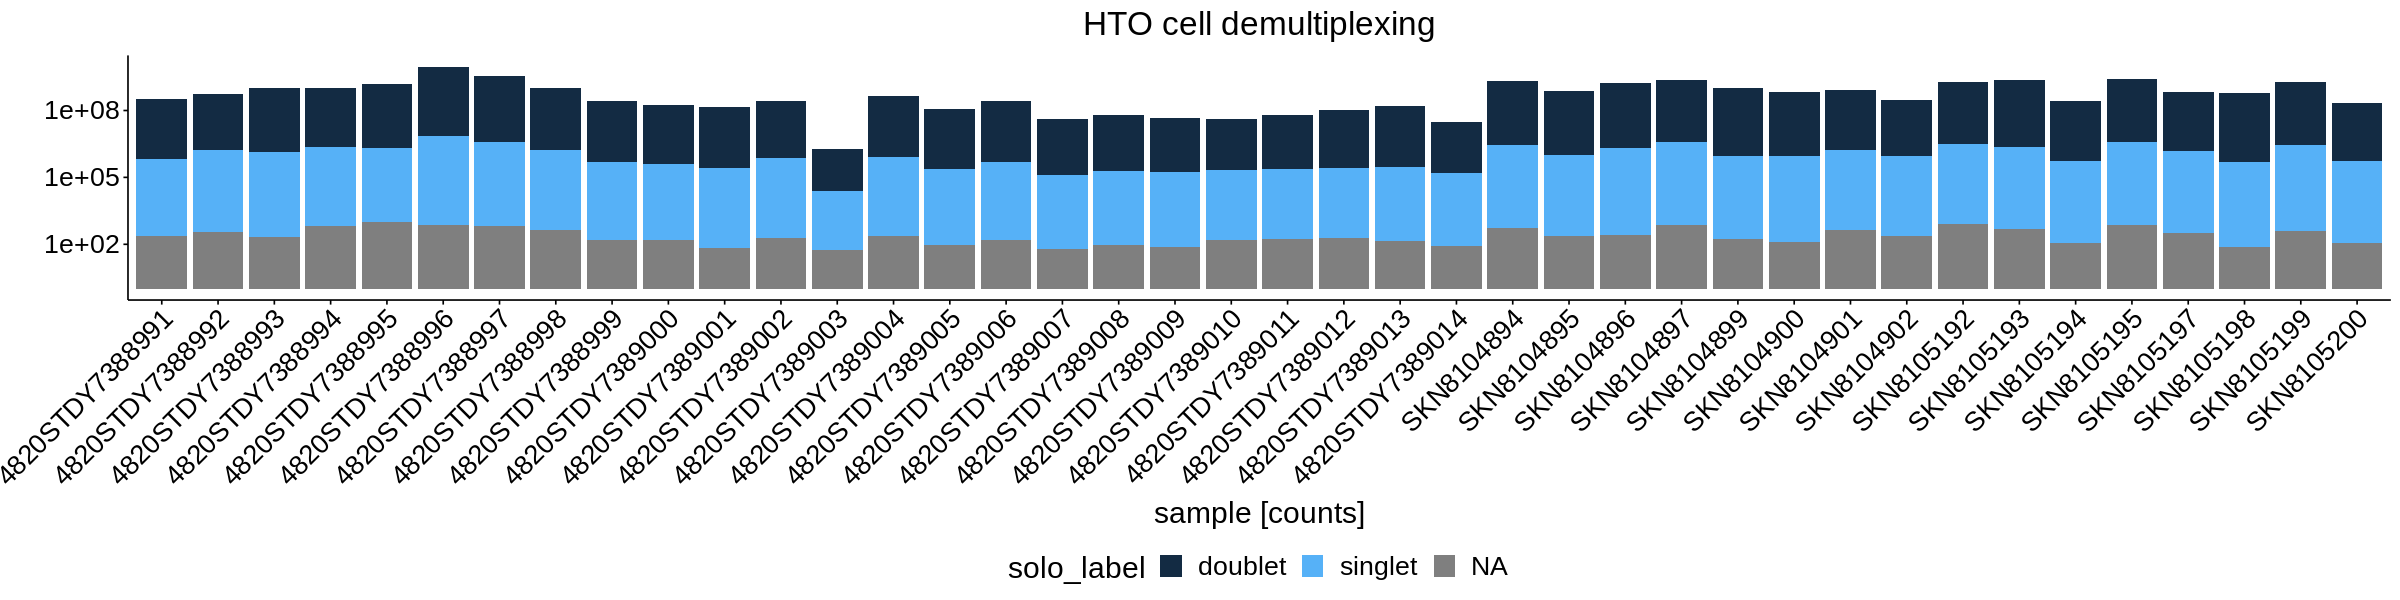

In [16]:
options(repr.plot.width=20, repr.plot.height=5)

ggplot(so_qc@meta.data, aes(x=sample_id, fill=solo_label)) + 
    geom_bar() + 
    xlab("sample [counts]") + ylab("") + ggtitle("HTO cell demultiplexing") + 
    # facet_grid(~patient_id) + 
    scale_fill_manual(values=c("#132B43", "#56B1F7", "#8c8c8c", "#ffc425")) + 
    scale_y_log10() + 
    theme(
        axis.text.x=element_text(angle=45, vjust=1, hjust=1), 
        legend.position="bottom"
    )

# Set Seurat object QC class

In [17]:
qc_class_set <- function(so) {
    
    # Set QC thresholds
    so$pMT_RNA_min <- -Inf
    so$pMT_RNA_max <- 15
    
    so$pHB_RNA_min <- -Inf
    so$pHB_RNA_max <- 5
    
    so$nCount_RNA_min <- 1000
    so$nCount_RNA_max <- max(so$nCount_RNA)

    so$qc_class <- ifelse(
        so$nCount_RNA <= so$nCount_RNA_max & 
        so$nCount_RNA > so$nCount_RNA_min &
        so$pMT_RNA <= so$pMT_RNA_max &
        so$pMT_RNA > so$pMT_RNA_min & 
        so$pHB_RNA <= so$pHB_RNA_max &
        so$pHB_RNA > so$pHB_RNA_min & 
        so$celltypist_predicted_labels_low != "Early erythroid" & 
        so$celltypist_predicted_labels_low != "Megakaryocyte-erythroid-mast cell progenitor" & 
        so$celltypist_predicted_labels_low != "Mid erythroid" & 
        so$celltypist_predicted_labels_high != "Erythroid" & 
        so$solo_label == "singlet" & 
        so$solo_mad_label == "singlet", 
        "pass", "fail"
      )
    
    # Set percentile threshold for feature count  
    so_tmp <- subset(so, subset=qc_class=="pass")
    
    so$nFeature_RNA_max <- max(so_tmp$nFeature_RNA)
    so$nFeature_RNA_min <- quantile(so_tmp$nFeature_RNA, 0.01)
    
    # Filter data 
    so$qc_class <- ifelse(
        so$qc_class == "pass" &
        so$nFeature_RNA <= so$nFeature_RNA_max & 
        so$nFeature_RNA > so$nFeature_RNA_min, 
        "pass", "fail"
      )
    

    return(so)

}

In [18]:
so_qc <- Seurat::SplitObject(so_qc, split.by="sample_id")
so_qc <- lapply(so_qc, qc_class_set)
so_qc <- merge(so_qc[[1]], so_qc[2:length(so_qc)])

# UMI and Feature count 

## Density plot

In [19]:
density_plot_qc_1 <- density_plot_qc(so=so_qc, title="Density plot UMI count", x=nCount_RNA, xlab="log10(UMI count)", min=nCount_RNA_min, max=nCount_RNA_max, formula=~sample_id) + facet_wrap(~sample_id, nrow=5)
density_plot_qc_2 <- density_plot_qc(so=so_qc, title="Density plot Feature count", x=nFeature_RNA, xlab="log10(Feature count)", min=nFeature_RNA_min, max=nFeature_RNA_max, formula=~sample_id) + facet_wrap(~sample_id, nrow=5)
density_plot_qc_3 <- density_plot_qc(so=so_qc, title="Density plot Mt %", x=pMT_RNA, xlab="Mt [%]", min=0, max=pMT_RNA_max, xlim=c(0,25), log10=FALSE, formula=~sample_id) + facet_wrap(~sample_id, nrow=5)

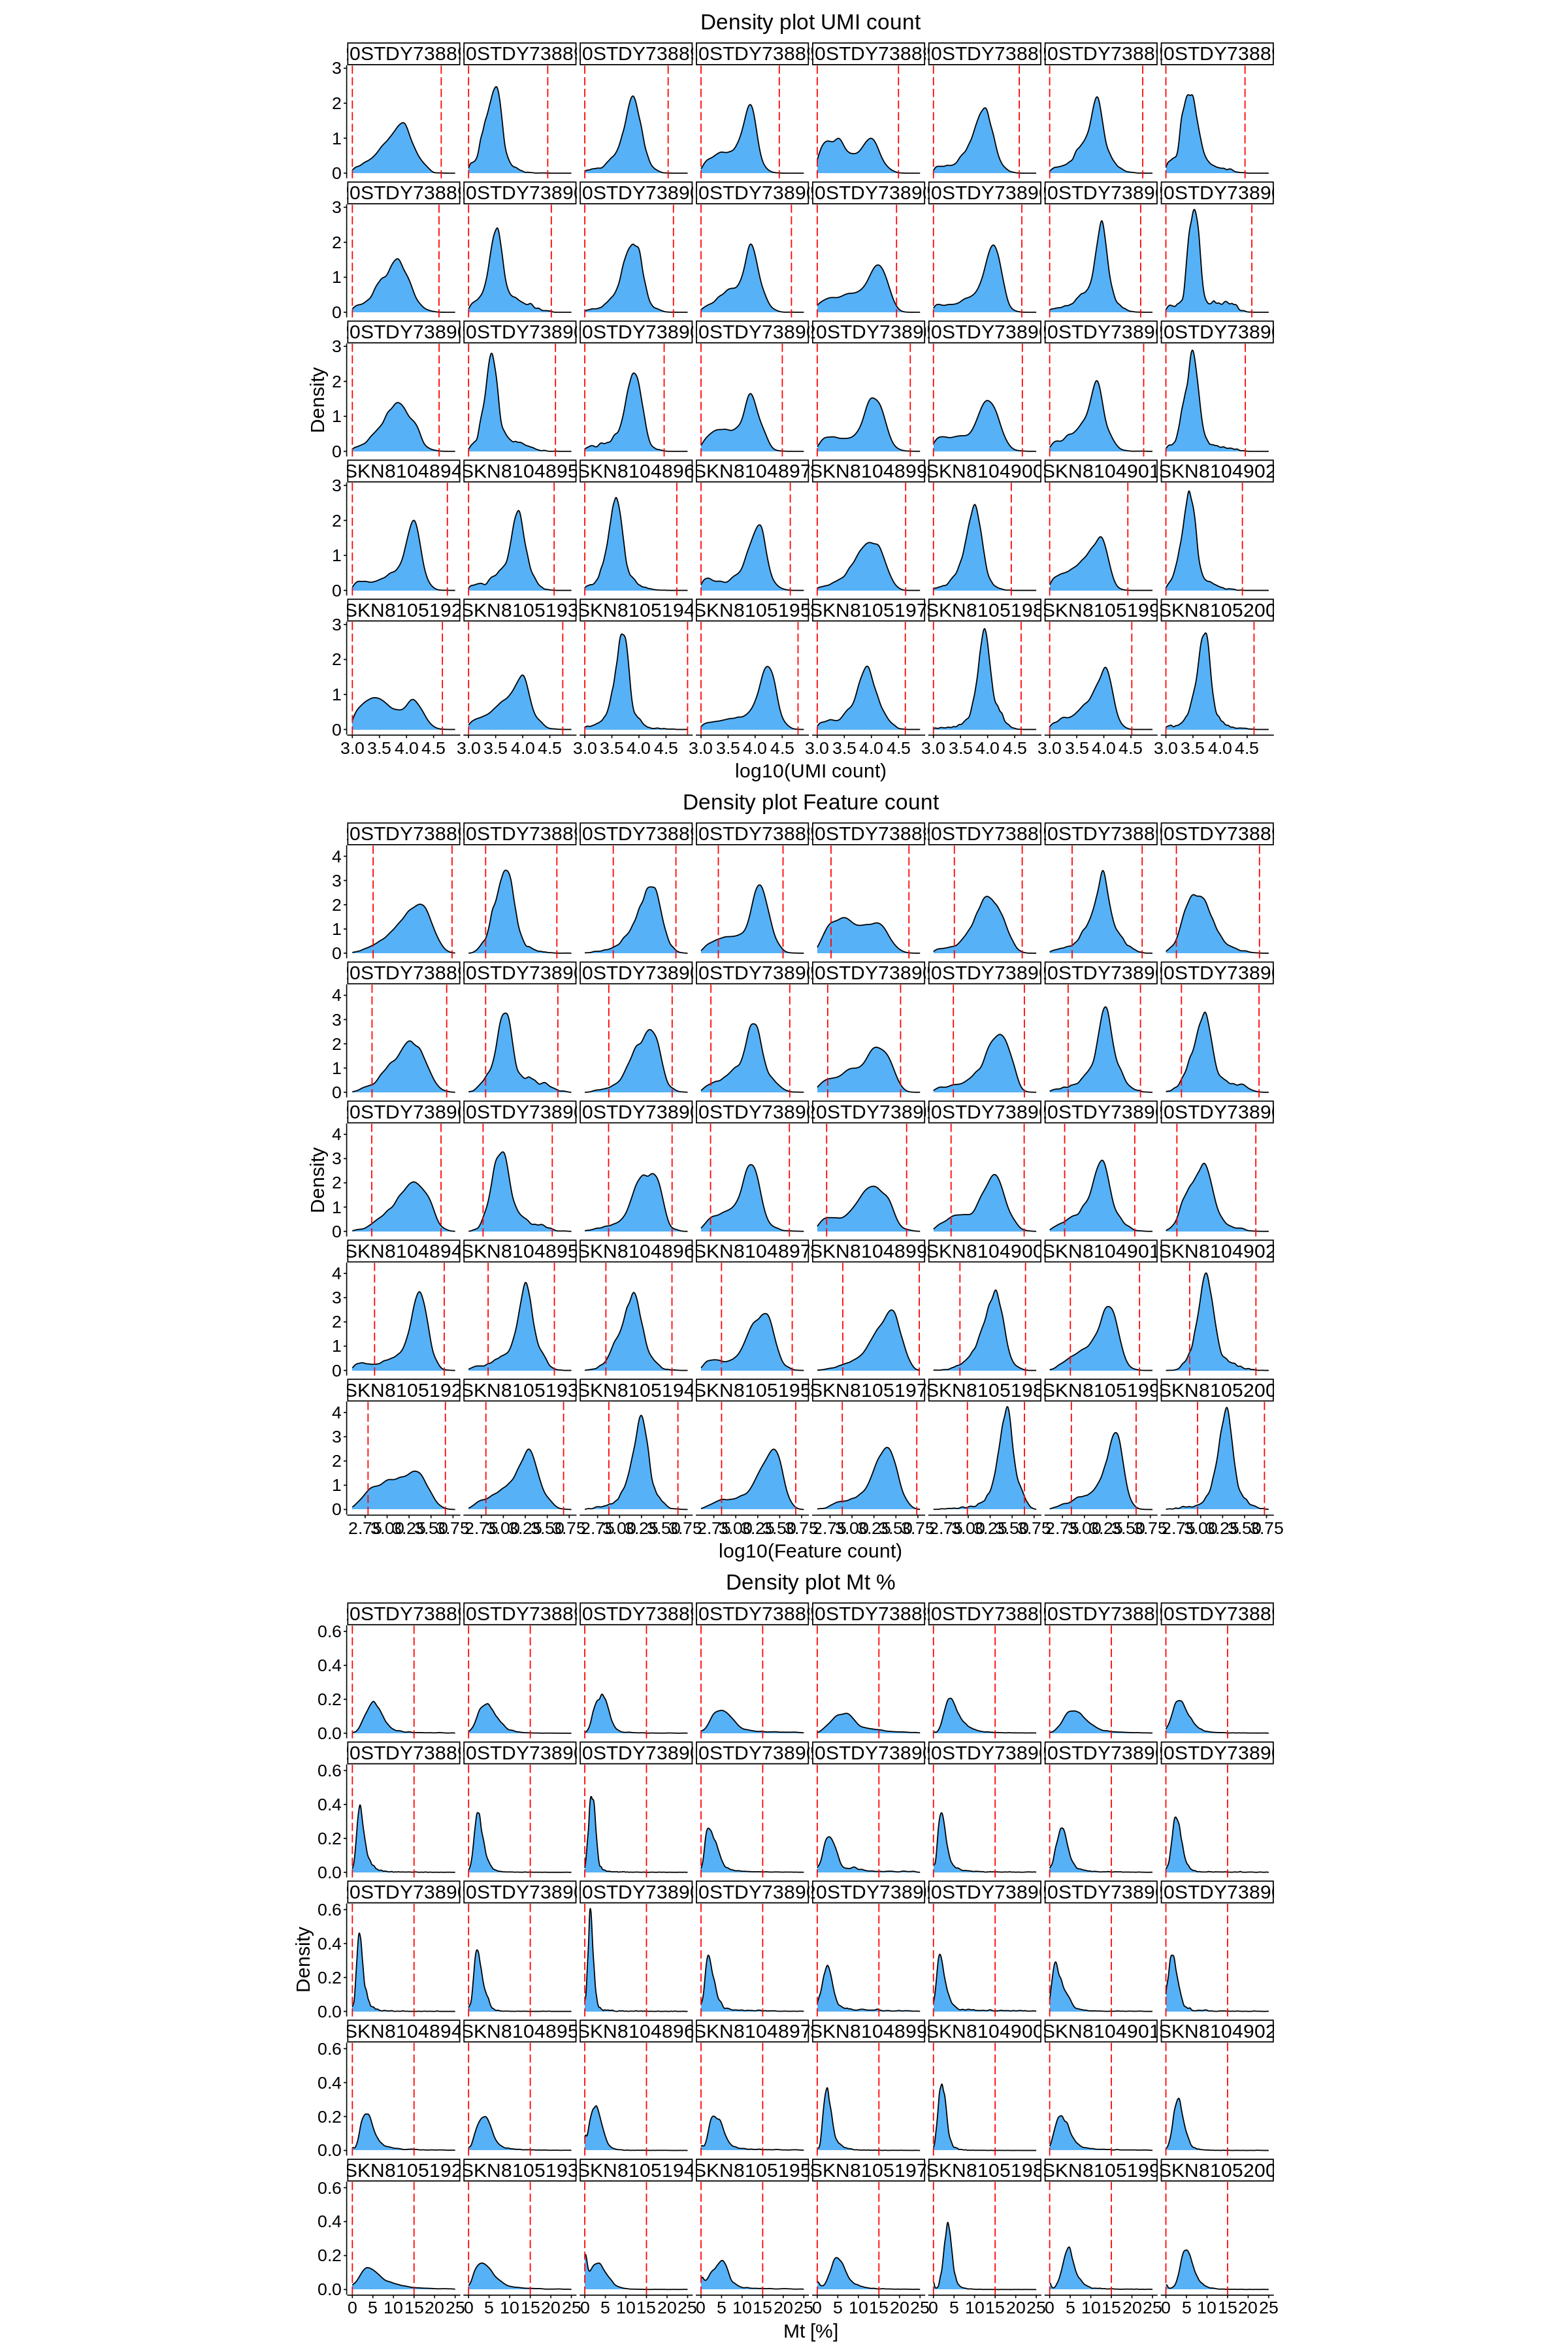

In [20]:
options(repr.plot.width=20, repr.plot.height=3*10)
density_plot_qc_1 + density_plot_qc_2 + density_plot_qc_3 + plot_layout(ncol=1) & theme(legend.position="none")

## Scattern plot

In [21]:
scattern_plot_qc_1 <- scattern_plot_qc(so=so_qc, title="Mitochondrial gene percentage", fill=pMT_RNA, formular=~sample_id) + facet_wrap(~sample_id, nrow=5)
scattern_plot_qc_2 <- scattern_plot_qc(so=so_qc, title="Hemoglobin gene percentage", fill=pHB_RNA, formular=~sample_id) + facet_wrap(~sample_id, nrow=5)
scattern_plot_qc_3 <- scattern_plot_qc(so=so_qc, title="Ribsonmal gene percentage", fill=pRP_RNA, formular=~sample_id) + facet_wrap(~sample_id, nrow=5)
scattern_plot_qc_4 <- scattern_plot_qc(so=so_qc, title="QC class", fill=qc_class, formular=~sample_id) + facet_wrap(~sample_id, nrow=5) + scale_color_manual(values=c("fail"="#132B43", "pass"="#56B1F7"))
scattern_plot_qc_5 <- scattern_plot_qc(so=so_qc, title="SOLO doublet class", fill=solo_label, formular=~sample_id) + facet_wrap(~sample_id, nrow=5) + scale_color_manual(values=c("doublet"="#132B43", "singlet"="#56B1F7"))

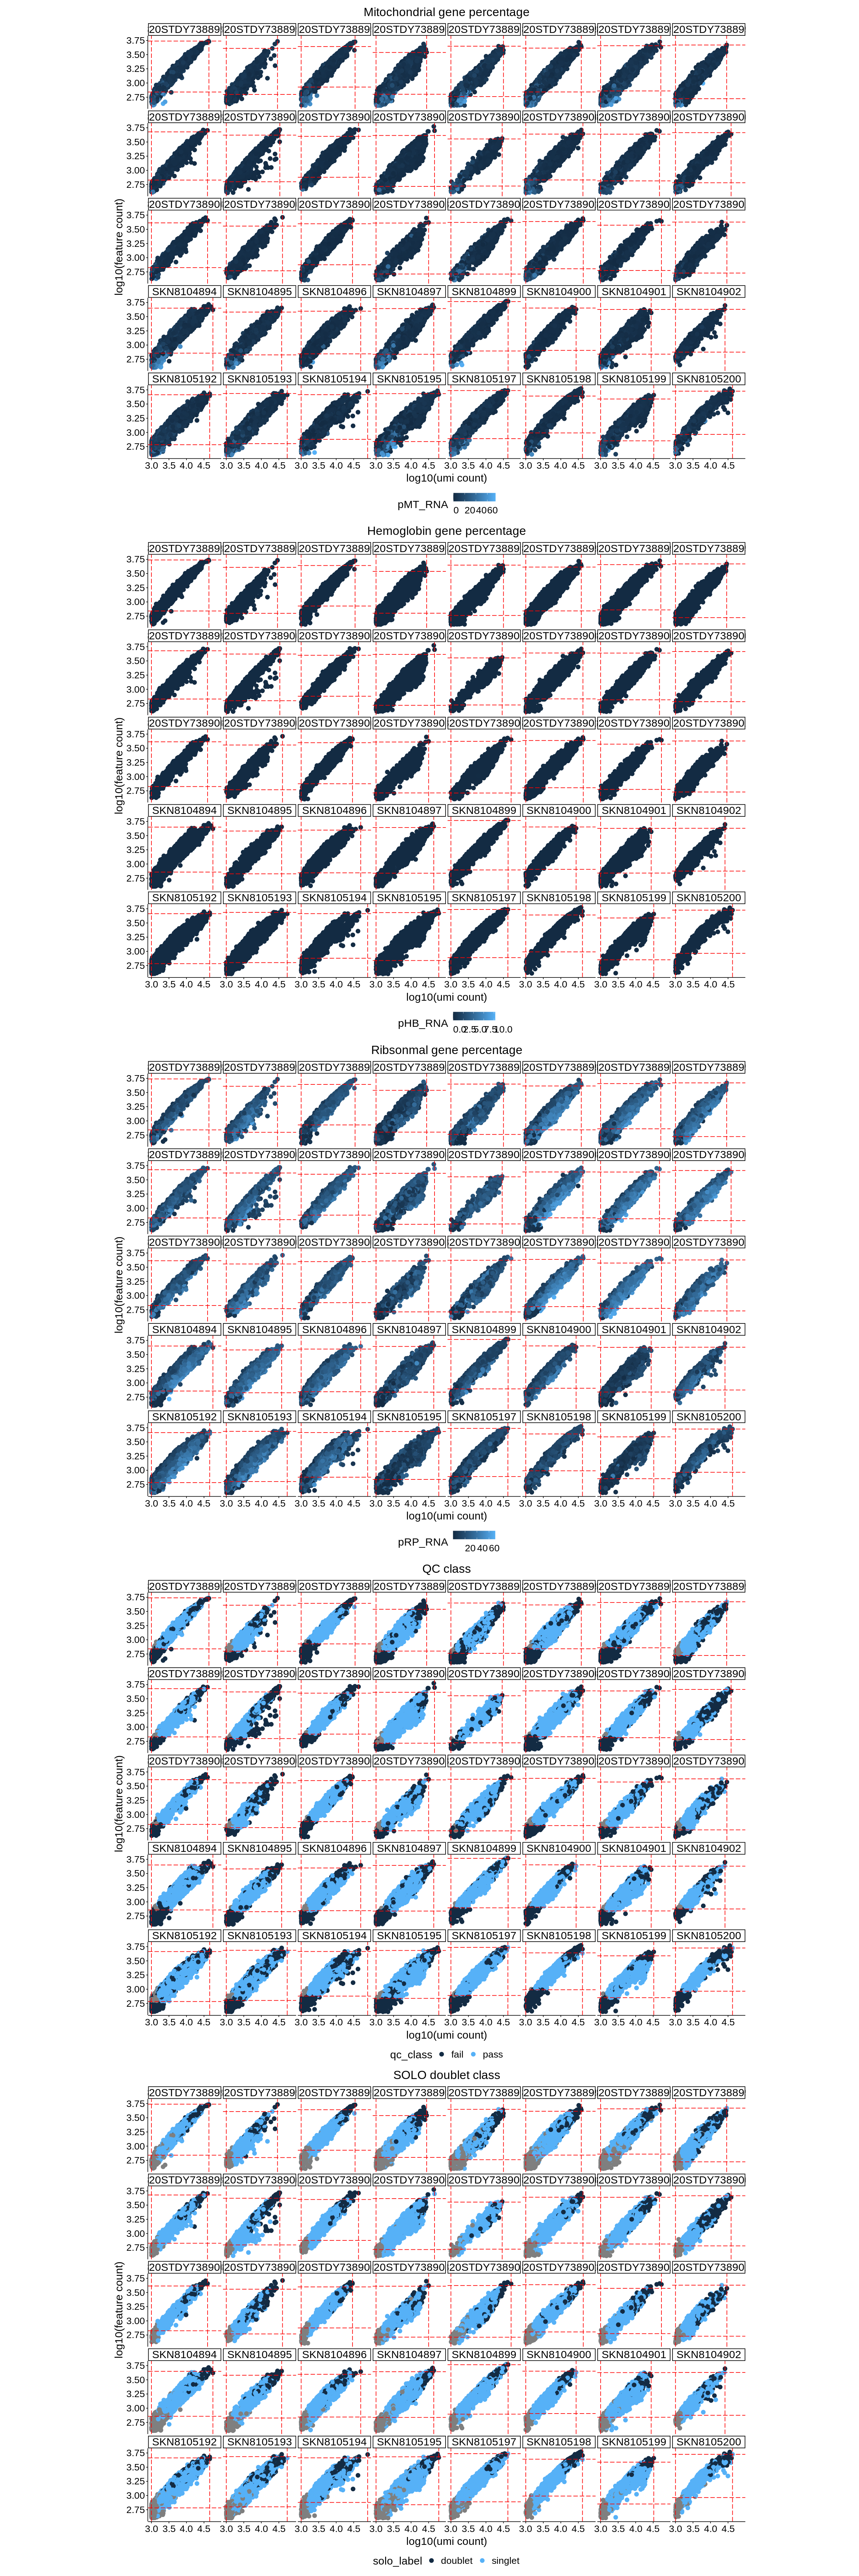

In [22]:
options(repr.plot.width=20, repr.plot.height=6*10)
scattern_plot_qc_1 + scattern_plot_qc_2 + scattern_plot_qc_3 + scattern_plot_qc_4 + scattern_plot_qc_5 + plot_layout(ncol=1) & theme(legend.position="bottom")

# Filter cells by QC class

In [23]:
so_qc <- subset(so_qc, subset=qc_class=="pass")

# Filter genes 

In [24]:
cnt <- GetAssayData(so_qc, assay="RNA", slot="counts")
cnt <- cnt[rowSums(cnt>3)>1, ]

In [25]:
so_qc <- CreateSeuratObject(counts=cnt, meta.data=so_qc@meta.data, project="reynolds_human_adult_healthy")

# Save results

In [ ]:
saveRDS(so_qc, qc_rds_file)

In [29]:
# Store data as h5ad 
adata <- import("anndata", as="adata", convert=FALSE)
pd <- import("pandas", as="pd", convert=FALSE)
np <- import("numpy", as="np", convert=FALSE)
    
# Transform dgCMatrix to sparse sc_sparse matrix
X <- GetAssayData(so_qc, assay="RNA", slot="counts")    
X <- adata$AnnData(X=X)$X$T

adata <- adata$AnnData(X=X, obs=so_qc@meta.data)
adata$var_names <- rownames(GetAssayData(so_qc, assay="RNA", slot="counts"))

adata$raw <- adata
adata$write_h5ad(qc_h5ad_file)

None

# Session info

In [ ]:
sessionInfo()